# Математическая статистика для анализа больших данных
## Задание 5
### Проверка гипотез.

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [5]:
# Bot check

# HW_ID: sbd_hw5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Задача 1 (3 балла)

Выведите формулу мощности для критерия Вальда при в случае односторонних альтернатив и формулу pvalue.

---
При проверке гипотезы $H_0: \theta = \theta_0$ $ vs. $ $H_1: \theta > \theta_0$, статистика критерия Вальда определяется как:

$$
W = \frac{\hat{\theta} - \theta_0}{\text{Var}(\hat{\theta})},
$$


Мощность критерия — это вероятность правильно отвергнуть $H_0$ при истинном значении параметра $\theta$, из лекции:

$$
\beta(\theta) = P_{\theta}(W > z_{1-\alpha}) = 1 - \Phi\left(z_{1-\alpha} - \frac{\theta - \theta_0}{\text{Var}(\hat{\theta})}\right),
$$

где $\Phi$ — функция распределения стандартного нормального распределения, а $z_{1-\alpha}$ — квантиль уровня $1-\alpha$.


Значение p-value для наблюдаемого значения статистики $W_{\text{obs}}$:

$$
p\text{-value} = 1 - \Phi(W_{\text{obs}}).
$$

---

### Задача 2 (4 балла)

Пусть $X_1, \dots, X_n \sim Bern(\theta)$, и мы проверяем гипотезу $\mathsf{H}_0\colon \theta = 1/2$ vs. $\mathsf{H}_1\colon \theta > 1/2$. Для проверки такой гипотезы можно использовать односторонний критерий Вальда. Выпишите формулу для статистики $W(X)$ критерия Вальда:

---
Оценка параметра $\theta$ — это выборочная доля успехов:

$$
\hat{\theta} = \frac{1}{n} \sum_{i=1}^{n} X_i.
$$

Дисперсия этой оценки при $H_0$:

$$
\text{Var}(\hat{\theta}) = \frac{\theta_0(1 - \theta_0)}{n} = \frac{\frac{1}{2} \times \frac{1}{2}}{n} = \frac{1}{4n}.
$$

Статистика критерия Вальда:

$$
W(X) = \frac{\hat{\theta} - \frac{1}{2}}{\text{Var}(\hat{\theta})} = 2 \sqrt{n} \left(\hat{\theta} - \frac{1}{2}\right).
$$

----

Обычно рассматривают критерии уровня значимости $0.05$. Это значит, что ошибка 1 рода у него не больше $0.05$. То есть отвержение при справедливости нулевой гипотезы происходит не больше чем в $5\%$ случаев. Однако критерий Вальда асимптотический. Поэтому для конечных размеров выборки уровень значимости может быть и больше. Вероятность ошибки 1 рода для фиксированного размера выборки называется *реальным уровнем значимости*. Чтобы оценить его для размера выборки $n$, нужно сгенерировать большое количество (например, $10000$) выборок размера $n$, где нулевая гипотеза справедлива, и оценить посчитать долю отвержений.

Напишите функцию, которая оценивает реальный уровень значимости для заданного размера выборки, посмотрите на её результаты для нескольких размеров выборки.

In [9]:
def get_significance_level(sample_size, n_samples=10000):
    """Вычисляет реальный уровень значимости

    Параметры:
        sample_size (int): размер выборки
        n_samples (int): количество выборок для семплирования

    Возвращает:
        float - оценка реального уровня значимости
        для размера выборки sample_size
    """
    samples = np.random.binomial(1, 0.5, size=(n_samples, sample_size))
    theta_hat = samples.mean(axis=1)
    W = 2 * np.sqrt(sample_size) * (theta_hat - 0.5)
    z_alpha = norm.ppf(0.95)

    rejections = (W > z_alpha).sum()
    significance_level = rejections / n_samples

    return significance_level

In [15]:
sample_sizes_to_test = [10, 50, 100, 150, 200, 300, 500]

for n in sample_sizes_to_test:
    significance = get_significance_level(n)
    print(f"Размер выборки: {n}, Реальный уровень значимости: {significance:.4f}")

Размер выборки: 10, Реальный уровень значимости: 0.0512
Размер выборки: 50, Реальный уровень значимости: 0.0605
Размер выборки: 100, Реальный уровень значимости: 0.0458
Размер выборки: 150, Реальный уровень значимости: 0.0464
Размер выборки: 200, Реальный уровень значимости: 0.0495
Размер выборки: 300, Реальный уровень значимости: 0.0452
Размер выборки: 500, Реальный уровень значимости: 0.0494


Реальный уровень значимости приближается к 0.05 с увеличением размера выборки, начиная с выборки 100 и выше. Это свидетельствует о том, что для больших выборок 0.05 является надежным уровнем значимости, обеспечивая стабильные результаты.

---

Постройте график зависимости реального уровня значимости от размера выборки. Сделайте выводы. С какого момента ошибка первого рода всегда меньше $5\%$?

Чтобы не генерировать выборки отдельно для каждого размера, можете сгенерировать их один раз, а в качестве выборок меньшего размера рассматривать префиксы получившихся больших выборок. Попробуйте посчитать отвержения только на `numpy`, не используя циклы.

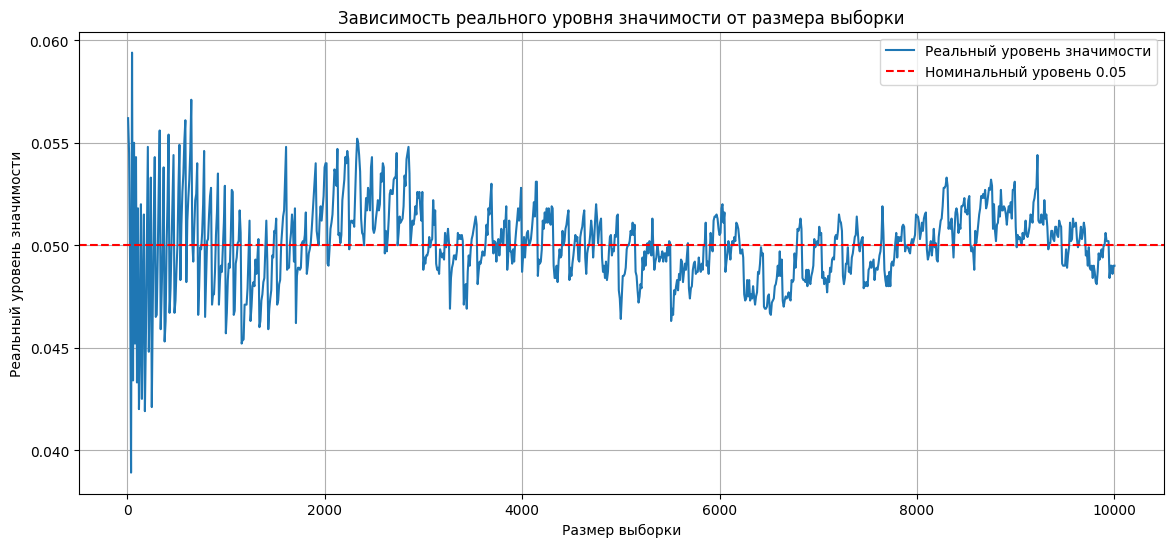

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n_samples = 10000
sample_sizes = np.arange(10, 10010, 10)
max_sample_size = sample_sizes.max()

alpha = 0.05
z_alpha = norm.ppf(1 - alpha)

all_samples = np.random.binomial(1, 0.5, size=(n_samples, max_sample_size))
cumulative_sums = np.cumsum(all_samples, axis=1)
indices = sample_sizes - 1
cumulative_sums_at_sizes = cumulative_sums[:, indices]
sample_sizes_reshaped = sample_sizes.reshape(1, -1)
theta_hat = cumulative_sums_at_sizes / sample_sizes_reshaped
W = 2 * np.sqrt(sample_sizes_reshaped) * (theta_hat - 0.5)
rejections = W > z_alpha
significance_levels = rejections.mean(axis=0)

plt.figure(figsize=(14, 6))
plt.plot(sample_sizes, significance_levels, label='Реальный уровень значимости')
plt.axhline(alpha, color='red', linestyle='--', label=f'Номинальный уровень {alpha}')
plt.xlabel('Размер выборки')
plt.ylabel('Реальный уровень значимости')
plt.title('Зависимость реального уровня значимости от размера выборки')
plt.legend()
plt.grid(True)
plt.show()

---
**Выводы:** График показывает зависимость реального уровня значимости критерия Вальда от размера выборки. Для малых выборок ($n < 500$) реальный уровень значимости значительно выше номинального уровня $0.05$, что свидетельствует о повышенной вероятности ошибки первого рода из-за несоответствия асимптотических предположений критерия. Это означает, что при небольших выборках критерий Вальда может быть ненадежным.

С увеличением размера выборки ($n \geq 500$) реальный уровень значимости стабилизируется вокруг $0.05$, что согласуется с теорией о том, что статистика критерия Вальда приближается к нормальному распределению при больших $n$. Таким образом, график подтверждает теоретические ожидания и указывает на необходимость осторожного применения критерия Вальда при малых выборках, рекомендуя использовать его преимущественно для больших выборок.




---
**Ответ:**

# Формула мощности для одностороннего критерия Вальда:

$$
\beta(\theta) = 1 - \Phi\left(z_{1-\alpha} - \frac{\theta - \theta_0}{\text{Var}(\hat{\theta})}\right).
$$
---
# Формула p-value:

$$
p\text{-value} = 1 - \Phi(W_{\text{obs}}).
$$
---

# Формула статистики критерия Вальда:

$$
W(X) = 2 \sqrt{n} \left(\hat{\theta} - \frac{1}{2}\right).
$$
---
---